In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Find repo root (notebook may run with cwd = repo or notebooks/)
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "notebooks").is_dir() and REPO_ROOT.name != "workspace":
    REPO_ROOT = REPO_ROOT.parent if (REPO_ROOT.parent / ".env").exists() else REPO_ROOT
elif (REPO_ROOT / "notebooks").is_dir() and (REPO_ROOT / ".env").exists():
    pass  # cwd is repo root
elif REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

load_dotenv(REPO_ROOT / ".env", override=False)

if os.environ.get("ROBOFLOW_API_KEY"):
    os.environ.setdefault("API_KEY", os.environ["ROBOFLOW_API_KEY"])

assert os.environ.get("HF_TOKEN"), "Set HF_TOKEN in .env"
assert os.environ.get("ROBOFLOW_API_KEY"), "Set ROBOFLOW_API_KEY in .env"
print("API keys loaded from .env")

API keys loaded from .env


In [2]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"

In [3]:
from IPython.display import Video
from typing import Dict, List, Optional, Union, Iterable, Tuple
from operator import itemgetter

import cv2
import numpy as np
import torch
from tqdm import tqdm

import supervision as sv
from inference import get_model
from sports import (
    clean_paths,
    ConsecutiveValueTracker,
    TeamClassifier,
    MeasurementUnit,
    ViewTransformer
)

ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
[transformers] `DepthProImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `DepthProImageProcessor` instead.
ModelDependencyMissing: Your `inference` configuration does not support YoloWorld model. Use pip install 'inference[yolo-world]' to install missing requirements.To suppress this warning, set CORE_MODEL_YOLO_WORLD_ENABLED to False.


In [ ]:
SOURCE_VIDEO_DIRECTORY = Path()
SOURCE_VIDEO_PATH = Path("data/boston-celtics-new-york-knicks-game-1-q2-10.36-10.32.mp4")

In [5]:
PLAYER_DETECTION_MODEL_ID = "basketball-player-detection-3-ycjdo/4"
PLAYER_DETECTION_MODEL_CONFIDENCE = 0.4
PLAYER_DETECTION_MODEL_IOU_THRESHOLD = 0.9
PLAYER_DETECTION_MODEL = get_model(model_id=PLAYER_DETECTION_MODEL_ID)

COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

In [6]:
STRIDE = 30
PLAYER_CLASS_IDS = [3, 4, 5, 6, 7] # player, player-in-possession, player-jump-shot, player-layup-dunk, player-shot-block
crops = []

for video_path in sv.list_files_with_extensions(SOURCE_VIDEO_DIRECTORY, extensions=["mp4", "avi", "mov"]):
    frame_generator = sv.get_video_frames_generator(source_path=video_path, stride=STRIDE)

    for frame in tqdm(frame_generator):

        result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD, class_agnostic_nms=True)[0]
        detections = sv.Detections.from_inference(result)
        detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]

        boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
        for box in boxes:
            crops.append(sv.crop_image(frame, box))

In [7]:
import gc

team_classifier = TeamClassifier(device="cuda")
team_classifier.fit(crops)

team_classifier.features_model.to("cpu")
team_classifier.device = "cpu"

gc.collect()
torch.cuda.empty_cache()
print(f"GPU allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Embedding extraction: 0it [00:00, ?it/s]


ValueError: need at least one array to concatenate

In [8]:
import sys
from pathlib import Path

SAM2_DIR = Path(r"C:\Users\zecab\.gemini\antigravity-ide\scratch\segment-anything-2-real-time")
sys.path.insert(0, str(SAM2_DIR))

# Drop any already-imported official sam2
for name in list(sys.modules):
    if name == "sam2" or name.startswith("sam2."):
        del sys.modules[name]

from sam2.build_sam import build_sam2_camera_predictor

predictor = build_sam2_camera_predictor(
    "configs/sam2.1/sam2.1_hiera_t.yaml",
    str(SAM2_DIR / "checkpoints/sam2.1_hiera_tiny.pt"),
)

In [9]:
from __future__ import annotations

class SAM2Tracker:
    def __init__(self, predictor) -> None:
        self.predictor = predictor
        self._prompted = False

    def prompt_first_frame(self, frame: np.ndarray, detections: sv.Detections) -> None:
        if len(detections) == 0:
            raise ValueError("detections must contain at least one box")

        if detections.tracker_id is None:
            detections.tracker_id = list(range(1, len(detections) + 1))

        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            self.predictor.load_first_frame(frame)
            for xyxy, obj_id in zip(detections.xyxy, detections.tracker_id):
                bbox = np.asarray([xyxy], dtype=np.float32)
                self.predictor.add_new_prompt(
                    frame_idx=0,
                    obj_id=int(obj_id),
                    bbox=bbox,
                )

        self._prompted = True

    def propagate(self, frame: np.ndarray) -> sv.Detections:
        if not self._prompted:
            raise RuntimeError("Call prompt_first_frame before propagate")

        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            tracker_ids, mask_logits = self.predictor.track(frame)

        tracker_ids = np.asarray(tracker_ids, dtype=np.int32)
        masks = (mask_logits > 0.0).cpu().numpy()
        masks = np.squeeze(masks).astype(bool)

        if masks.ndim == 2:
            masks = masks[None, ...]

        masks = np.array([
            sv.filter_segments_by_distance(mask, relative_distance=0.03, mode="edge")
            for mask in masks
        ])

        xyxy = sv.mask_to_xyxy(masks=masks)
        detections = sv.Detections(xyxy=xyxy, mask=masks, tracker_id=tracker_ids)
        return detections

    def reset(self) -> None:
        self._prompted = False

In [10]:
NUMBER_RECOGNITION_MODEL_ID = "basketball-jersey-numbers-ocr/7"
NUMBER_RECOGNITION_MODEL = get_model(model_id=NUMBER_RECOGNITION_MODEL_ID)
NUMBER_RECOGNITION_MODEL_PROMPT = "Read the number."

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

In [11]:
def coords_above_threshold(
    matrix: np.ndarray, threshold: float, sort_desc: bool = True
) -> List[Tuple[int, int]]:
    """
    Return all (row_index, col_index) where value > threshold.
    Rows and columns may repeat.
    Optionally sort by value descending.
    """
    A = np.asarray(matrix)
    rows, cols = np.where(A > threshold)
    pairs = list(zip(rows.tolist(), cols.tolist()))
    if sort_desc:
        pairs.sort(key=lambda rc: A[rc[0], rc[1]], reverse=True)
    return pairs


def match_detector_to_tracker_id(
    event_detections: sv.Detections,
    player_detections: sv.Detections,
    iou_threshold: float = 0.3,
) -> Optional[int]:
    """Map the best detector box for an event class to a SAM2 tracker_id."""
    if len(event_detections) == 0 or len(player_detections) == 0:
        return None

    best_idx = int(np.argmax(event_detections.confidence))
    event_box = event_detections.xyxy[best_idx:best_idx + 1]

    ious = sv.box_iou_batch(player_detections.xyxy, event_box).reshape(-1)
    matched_idx = int(np.argmax(ious))

    if ious[matched_idx] >= iou_threshold:
        return int(player_detections.tracker_id[matched_idx])
    return None

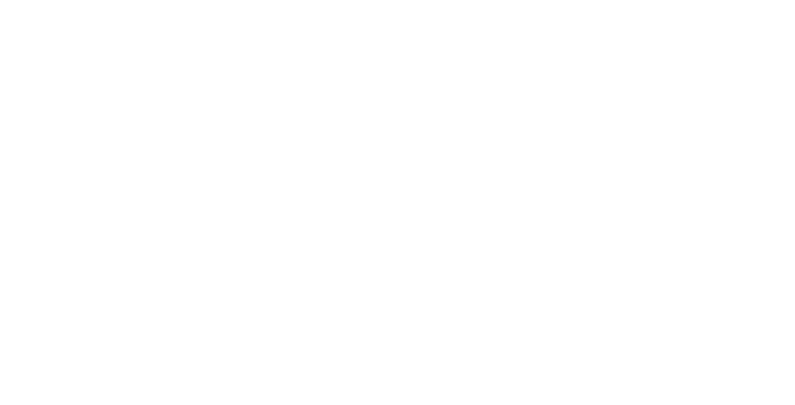

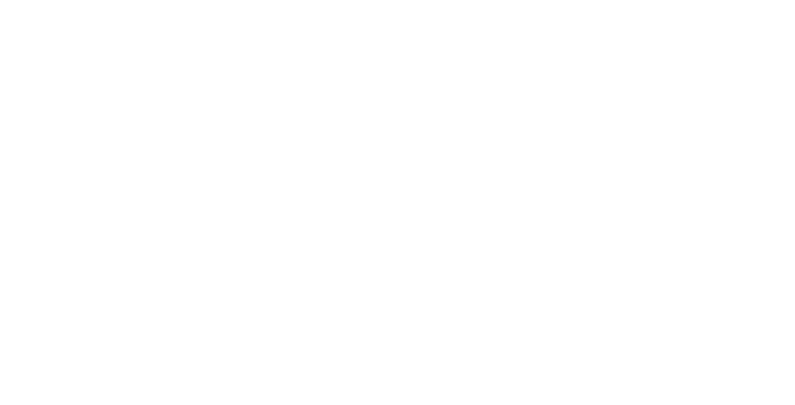

In [12]:
teams = team_classifier.predict(crops)

team_0 = [crop for crop, team in zip(crops, teams) if team == 0]
team_1 = [crop for crop, team in zip(crops, teams) if team == 1]

sv.plot_images_grid(
    images=team_0[:50],
    grid_size=(5, 10),
    size=(10, 5)
)

sv.plot_images_grid(
    images=team_1[:50],
    grid_size=(5, 10),
    size=(10, 5)
)

In [13]:
# TEAM_NAMES = {
#     0: "New York Knicks",
#     1: "Boston Celtics",
# }
TEAM_NAMES = {
    0: "Boston Celtics",
    1: "New York Knicks",
}

In [14]:
def match_detector_to_tracker_id(
    event_detections: sv.Detections,
    player_detections: sv.Detections,
    iou_threshold: float = 0.3,
) -> int | None:
    """Map the best detector box for an event class to a SAM2 tracker_id."""
    if len(event_detections) == 0 or len(player_detections) == 0:
        return None

    best_idx = int(np.argmax(event_detections.confidence))
    event_box = event_detections.xyxy[best_idx:best_idx + 1]

    ious = sv.box_iou_batch(player_detections.xyxy, event_box).reshape(-1)
    matched_idx = int(np.argmax(ious))

    if ious[matched_idx] >= iou_threshold:
        return int(player_detections.tracker_id[matched_idx])
    return None

In [ ]:
SOURCE_VIDEO_PATH = SOURCE_VIDEO_DIRECTORY / "boston-celtics-new-york-knicks-game-1-q1-0.16-03.11.mp4"

frames_history = []
player_detections_history = []
state_detections_history = []
other_detections_history = []

validated_numbers = set()
NUMBER_CLASS_ID = 2
OTHER_CLASS_IDS = [0, 1, 9] # ball, ball-in-rim, player, player-in-possession, player-jump-shot, player-layup-dunk, player-shot-block, rim

number_validator = ConsecutiveValueTracker(n_consecutive=3)
team_validator = ConsecutiveValueTracker(n_consecutive=1)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# we use RF-DETR model to aquire future SAM2 prompt

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)

# we determine the team for each player and assign a team ID to every detection

boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
crops = [sv.crop_image(frame, box) for box in boxes]
TEAMS = np.array(team_classifier.predict(crops))

team_validator.update(tracker_ids=detections.tracker_id, values=TEAMS)

# we prompt SAM2 using RF-DETR model detections

tracker = SAM2Tracker(predictor)
tracker.prompt_first_frame(frame, detections)

# we propagate tracks across all video frames

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

for index, frame in tqdm(enumerate(frame_generator)):
    player_detections = tracker.propagate(frame)
    #frames_history.append(frame)
    #player_detections_history.append(player_detections)

    # Ball handling tracking every frame
    result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
    all_detections = sv.Detections.from_inference(result)
    state_detections = all_detections[np.isin(all_detections.class_id, PLAYER_CLASS_IDS)]

    other_detections = all_detections[np.isin(all_detections.class_id, OTHER_CLASS_IDS)]

    # Clean duplicate player-state boxes
    state_detections = state_detections.with_nms(threshold=0.5,class_agnostic=True)
    #state_detections_history.append(state_detections)
    #other_detections_history.append(other_detections)
    # we perform number recognition at specific frame intervals
    unresolved = [
        tracker_id
        for tracker_id in player_detections.tracker_id
        if int(tracker_id) not in validated_numbers
    ]
    if index % 5 == 0 and unresolved:
        # print(index)
        frame_h, frame_w, *_ = frame.shape

        # we use RF-DETR model to detect numbers on player

        result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
        number_detections = sv.Detections.from_inference(result)
        number_detections = number_detections[number_detections.class_id == NUMBER_CLASS_ID]
        number_detections.mask = sv.xyxy_to_mask(boxes=number_detections.xyxy, resolution_wh=(frame_w, frame_h))

        # we crop out numbers detection and run recognition model

        number_crops = [
            sv.crop_image(frame, xyxy)
            for xyxy
            in sv.clip_boxes(sv.pad_boxes(xyxy=number_detections.xyxy, px=10, py=10), (frame_w, frame_h))
        ]
        number_results = [
            NUMBER_RECOGNITION_MODEL.infer(number_crop, prompt=NUMBER_RECOGNITION_MODEL_PROMPT)[0]
            for number_crop
            in number_crops
        ]

        numbers = [
            result.response.strip()
            for result in number_results
        ]

        # we use mask IoS to match numbers with players

        iou = sv.mask_iou_batch(
            masks_true=player_detections.mask,
            masks_detection=number_detections.mask,
            overlap_metric=sv.OverlapMetric.IOS
        )

        pairs = coords_above_threshold(iou, 0.9)

        if pairs:
            player_idx, number_idx = zip(*pairs)
            tracker_ids = player_detections.tracker_id[list(player_idx)]
            number_idx = list(number_idx)

            # we update number_validator state
            numbers = [numbers[int(i)] for i in number_idx]
            number_validator.update(tracker_ids, values=numbers)
            validated_numbers.update(tracker_ids.tolist()) # Added tracker_ids to the set


Exception: Could not open video at data\boston-celtics-new-york-knicks-game-1-q2-10.36-10.32